 # HeartDisease

# Problem Statement
#The model predicts whether a patient is likely to have heart disease or not based on the input medical features.

# Data Understanding

In [227]:
import pandas as pd      # for data Manipulation
import numpy as np       # for computational solving
import seaborn as sns     # Advanced Visualization Library
import matplotlib.pyplot as plt #data visulizasion
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [170]:
df=pd.read_csv(r"C:\Users\Sarvadnya\FUSIONCLASS\Projects\heart diase\heart_disease.csv")
df

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [171]:
column_names=df.columns
column_names

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

In [172]:
df.shape

(10000, 21)

In [173]:
df.isnull()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [174]:
df.isnull().sum()[df.isnull().sum() > 0]

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
dtype: int64

In [175]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = imputer.fit_transform(df[num_cols])

In [176]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy='most_frequent')

cat_cols = df.select_dtypes(include=['object']).columns

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [177]:
df.isna().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64

In [178]:
df.duplicated().sum()

np.int64(0)

In [179]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis (EDA)

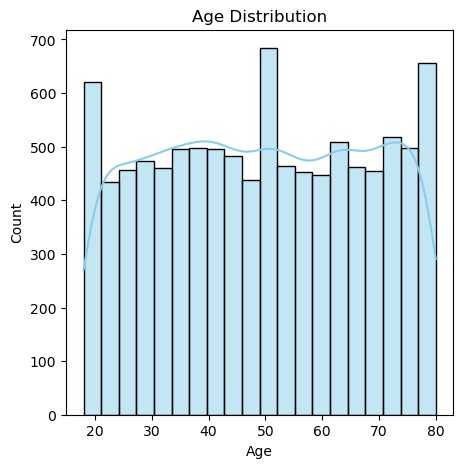

In [180]:
plt.figure(figsize=(5,5))
sns.histplot(df['Age'], bins=20, kde=True,color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

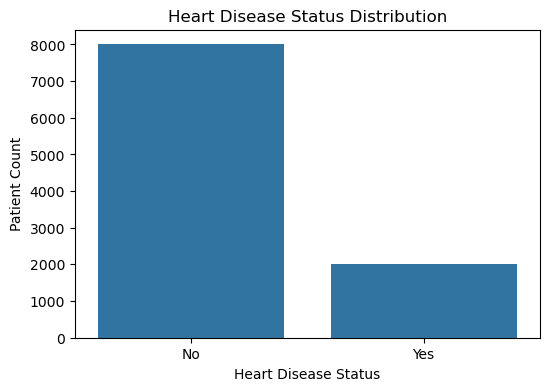

In [181]:
plt.figure(figsize=(6,4))
sns.countplot(x='Heart Disease Status', data=df)
plt.title("Heart Disease Status Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Patient Count")
plt.show()

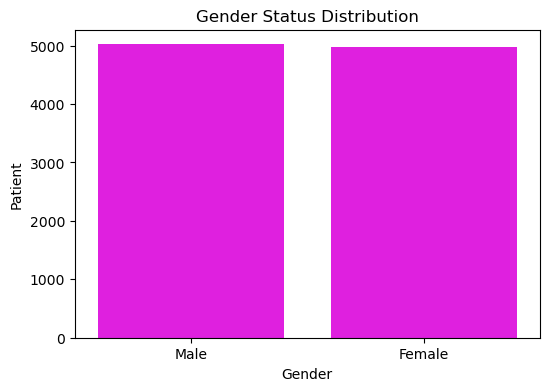

In [182]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df,color='magenta')
plt.title("Gender Status Distribution")
plt.xlabel("Gender")
plt.ylabel("Patient")
plt.show()

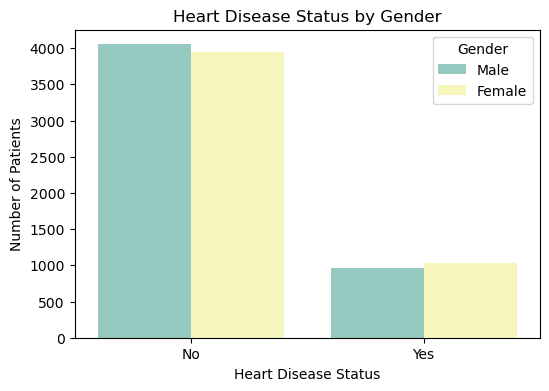

In [183]:
plt.figure(figsize=(6,4))
sns.countplot(x="Heart Disease Status", hue="Gender", data=df, palette='Set3')
plt.title("Heart Disease Status by Gender")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.show()

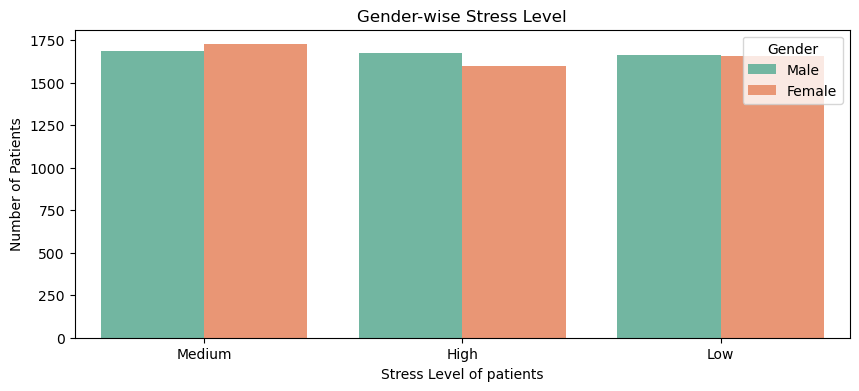

In [184]:
plt.figure(figsize=(10,4))
sns.countplot(x='Stress Level', hue="Gender", data=df, palette='Set2')
plt.title("Gender-wise Stress Level")
plt.xlabel("Stress Level of patients")
plt.ylabel("Number of Patients")
plt.show()

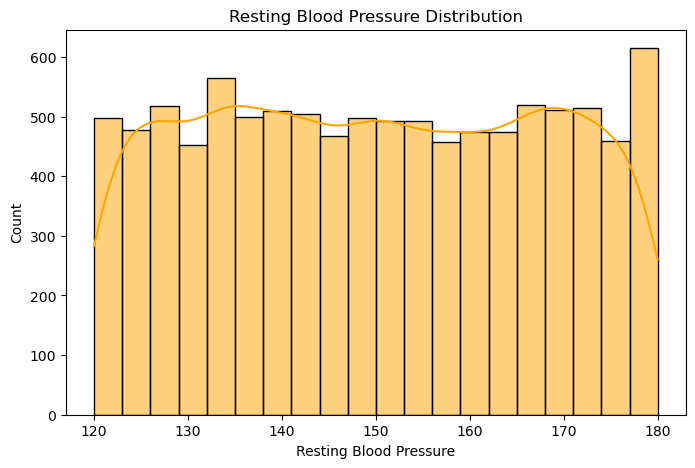

In [185]:
plt.figure(figsize=(8,5))
sns.histplot(df['Blood Pressure'], bins=20, kde=True,color='orange')
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Count")
plt.show()

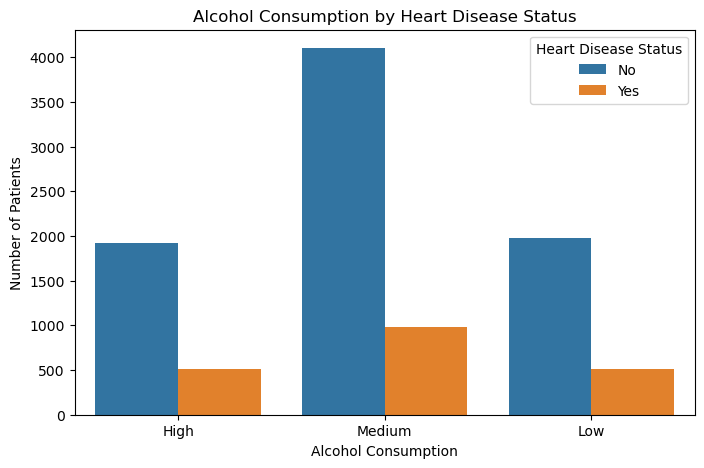

In [186]:
plt.figure(figsize=(8,5))
sns.countplot(x='Alcohol Consumption', hue='Heart Disease Status', data=df)
plt.title("Alcohol Consumption by Heart Disease Status")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Number of Patients")
plt.show()

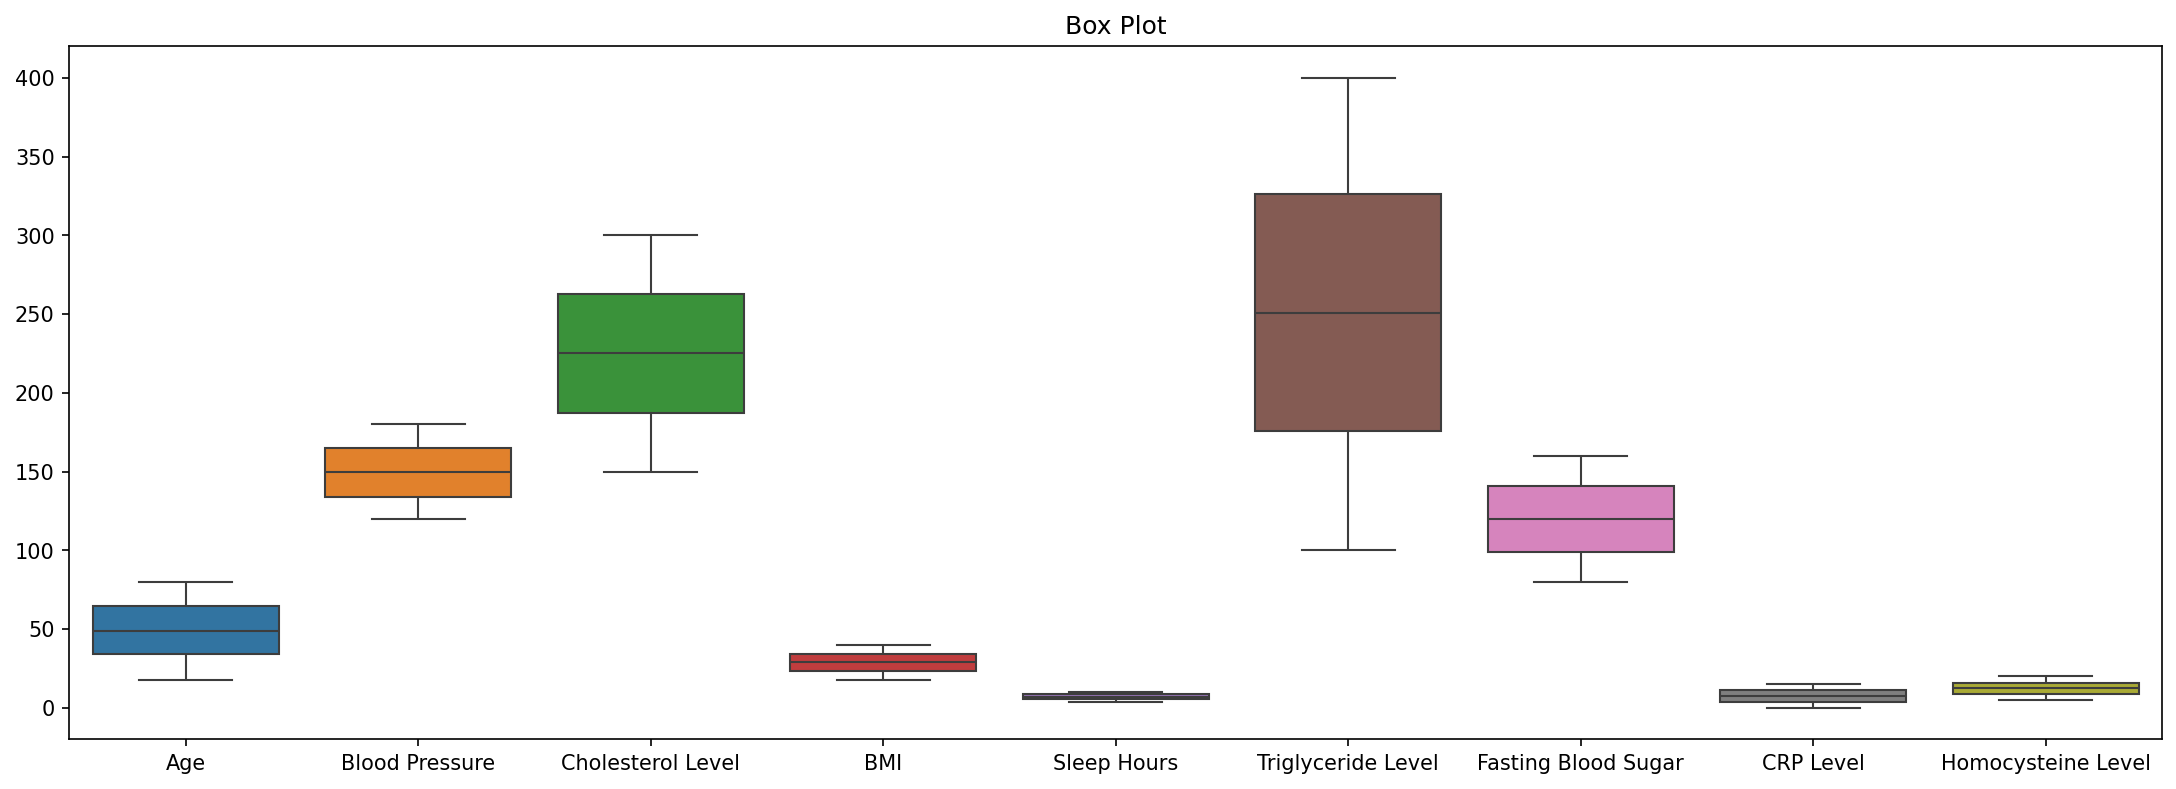

In [187]:
plt.figure(figsize=(18,6), dpi=150)
sns.boxplot(data=df)
plt.title("Box Plot")
plt.show()

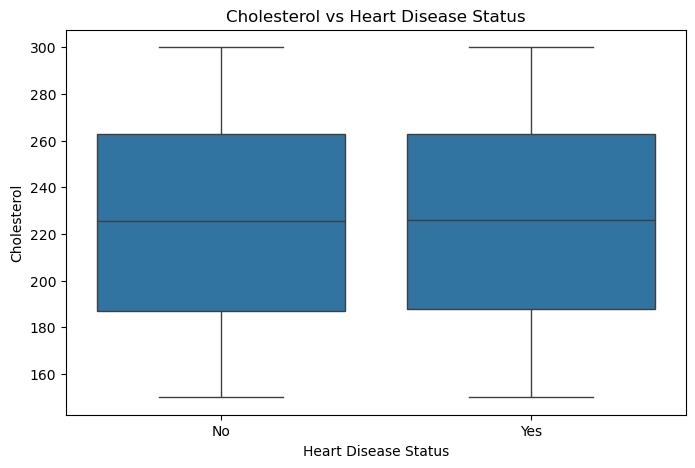

In [188]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Heart Disease Status', y='Cholesterol Level', data=df)
plt.title("Cholesterol vs Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Cholesterol")
plt.show()

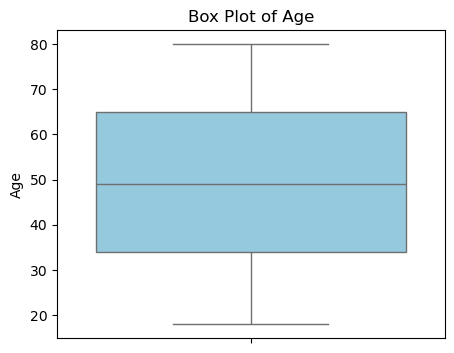

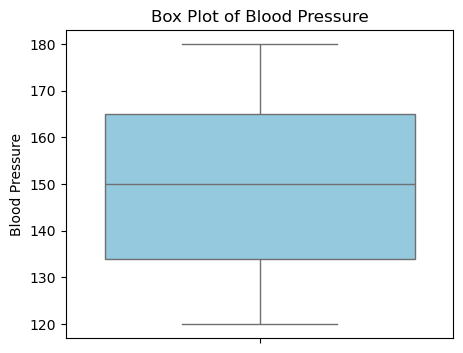

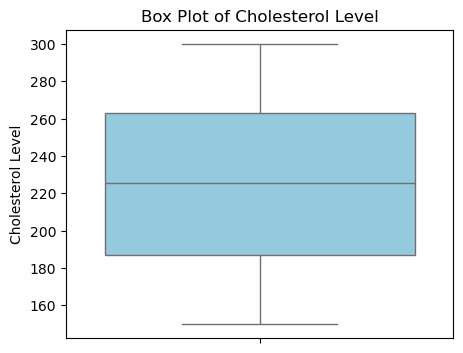

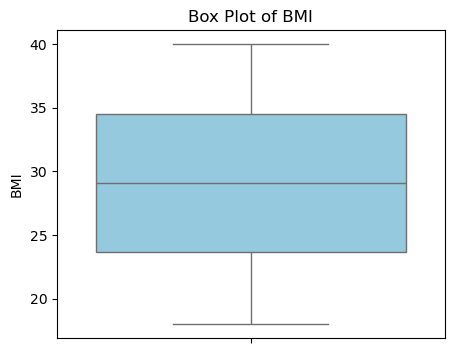

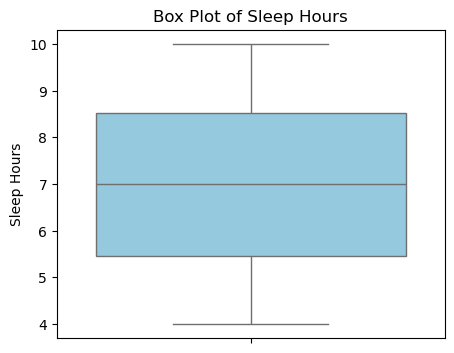

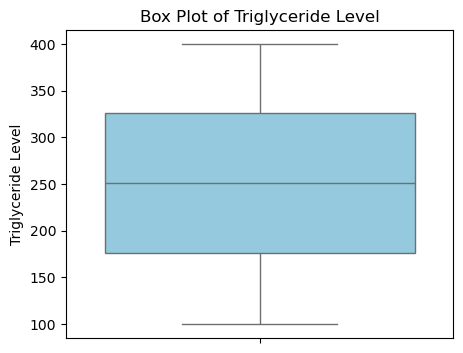

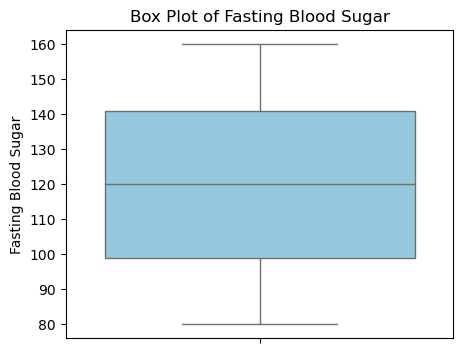

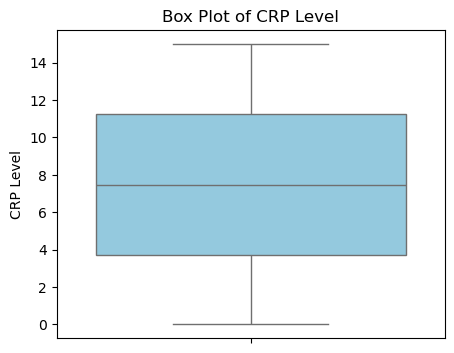

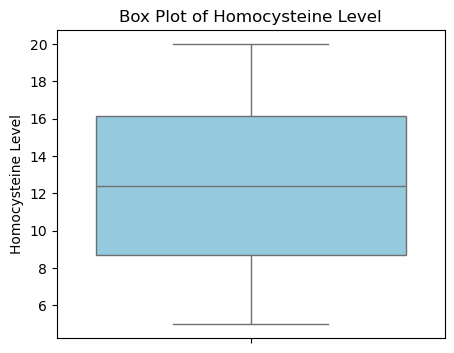

In [189]:
num_cols = ["Age", "Blood Pressure", "Cholesterol Level", "BMI",
            "Sleep Hours", "Triglyceride Level",
            "Fasting Blood Sugar", "CRP Level",
            "Homocysteine Level"]

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

In [190]:
df.skew(numeric_only=True) #Skewness is used to understand the distribution of numerical data. 
#It helps identify whether the data is symmetric, positively skewed, or negatively skewed. 
#This information is useful for selecting preprocessing techniques and appropriate machine learning models.

Age                   -0.006799
Blood Pressure         0.013921
Cholesterol Level     -0.007131
BMI                   -0.021366
Sleep Hours            0.000172
Triglyceride Level     0.006150
Fasting Blood Sugar   -0.008925
CRP Level             -0.004074
Homocysteine Level     0.007894
dtype: float64

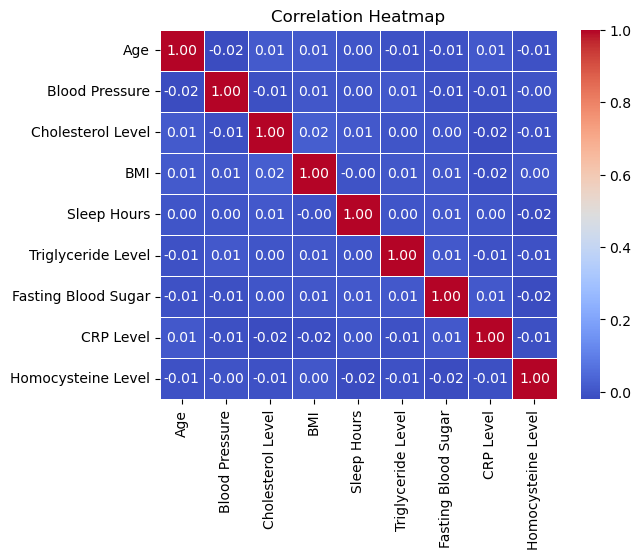

In [191]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Feature Selection (X & y)

In [192]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [193]:
X= df.drop('Heart Disease Status', axis=1)
y = df['Heart Disease Status']

In [194]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [195]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [198]:
X.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,56.0,1,153.0,155.0,0,1,1,0,24.991591,1,1,0,0,2,7.633228,2,342.0,120.142213,12.969246,12.387250
1,69.0,0,146.0,286.0,0,0,1,1,25.221799,0,1,0,2,0,8.744034,2,133.0,157.000000,9.355389,19.298875
2,46.0,1,126.0,216.0,1,0,0,0,29.855447,0,1,1,1,1,4.440440,1,393.0,92.000000,12.709873,11.230926
3,32.0,0,122.0,293.0,0,1,1,0,24.130477,1,0,1,1,0,5.249405,0,293.0,94.000000,12.509046,5.961958
4,60.0,1,166.0,242.0,1,1,1,1,20.486289,1,0,0,1,0,7.030971,0,263.0,154.000000,10.381259,8.153887


In [236]:
# improve accuracy
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))
#The warning occurred because the model did not predict any samples for the positive (Heart Disease) class.
#As a result, precision for that class became undefined and sklearn assigned it a value of 0.


Confusion Matrix

[[1613    0]
 [ 387    0]]

Classification Report

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1613
           1       0.00      0.00      0.00       387

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000



C:\Users\Sarvadnya\.jupyter\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sarvadnya\.jupyter\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sarvadnya\.jupyter\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [235]:
# improve recall
lr = LogisticRegression(class_weight='balanced', random_state=42)

# Train
lr.fit(X_train, y_train)

# Prediction
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_lr))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.493
Precision: 0.17580144777662876
Recall   : 0.4392764857881137
F1-Score : 0.2511078286558346
ROC-AUC  : 0.4725830662046582

Confusion Matrix

[[816 797]
 [217 170]]

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.51      0.62      1613
           1       0.18      0.44      0.25       387

    accuracy                           0.49      2000
   macro avg       0.48      0.47      0.43      2000
weighted avg       0.67      0.49      0.55      2000



In [242]:
import joblib

# Save Logistic Regression Model
joblib.dump(lr, "heart_model.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

print("Logistic Regression Model and Scaler saved successfully!")

Logistic Regression Model and Scaler saved successfully!
